In [303]:
"""Sparse real-space Green-function solver for a T^- initial exciton sector.

Basis sectors
-------------
    ("Tm",  R)        zero magnons
    ("S",   R, m)     one magnon, singlet combination
    ("T0",  R, m)     one magnon, triplet-zero combination
    ("Tp",  R, m, n)  two magnons on distinct sites, canonical order m < n
    ("TpD", R, m)     two spin-lowerings on the same site (absent for s = 1/2)

Conventions
-----------
    * The T^- state uses the 1/sqrt(2N) normalization.
    * The S and T0 one-magnon states use 1/sqrt(2 s N).
    * The two-magnon T^+ sector is split into "separated" and "double" states.
    * M(z, K) = z - H is assembled directly.
    * t_v is the code-sign valence hopping: t_v_code = - t_v_LaTeX.

The two-magnon Heisenberg part is written in normalized local-occupation
language, which reproduces the separated-to-double hopping coefficient
J_FM * sqrt(s (2s - 1)) and the adjacent-magnon Ising correction.
"""

import math
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Union

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# A basis key is a tagged tuple whose length depends on the sector.
Key = Union[
    Tuple[str, int],            # ("Tm", R)
    Tuple[str, int, int],       # ("S"/"T0"/"TpD", R, m)
    Tuple[str, int, int, int],  # ("Tp", R, m, n)
]


@dataclass(frozen=True)
class SolverSizes:
    """Per-sector basis-dimension breakdown."""
    n_total: int
    n_Tm: int
    n_S: int
    n_T0: int
    n_Tp_sep: int
    n_Tp_double: int


class ExcitonMagnonTminusSolver:
    """Green function (z - H)^{-1} for the T^- exciton-magnon problem.

    The Hamiltonian couples five sectors (see module docstring).  The basis is
    truncated by |R| <= Rmax and by keeping each magnon within M sites of either
    the electron (site 0) or the hole (site R).
    """

    # ------------------------------------------------------------------
    # Construction
    # ------------------------------------------------------------------
    def __init__(
        self,
        t_c, t_v, Delta, J_FM, Je, Jv, s, gamma, U, Rmax, M,
        *,
        allow_double_magnon: Optional[bool] = None,
        exact_two_magnon_spin: bool = True,
        permc_spec: str = "COLAMD",
    ):
        # Model parameters.
        self.t_c = float(t_c)
        self.t_v = float(t_v)
        self.Delta = float(Delta)
        self.J_FM = float(J_FM)
        self.Je = float(Je)
        self.Jv = float(Jv)
        self.s = float(s)
        self.gamma = float(gamma)
        self.U = float(U)

        # Truncation and solver options.
        self.Rmax = int(Rmax)
        self.M = int(M)
        self.exact_two_magnon_spin = bool(exact_two_magnon_spin)
        self.permc_spec = str(permc_spec)

        if self.s <= 0:
            raise ValueError("s must be positive")

        # The same-site double-lowering sector has zero norm at s = 1/2.
        if allow_double_magnon is None:
            allow_double_magnon = (2.0 * self.s - 1.0) > 1e-14
        self.allow_double_magnon = bool(allow_double_magnon)
        if self.allow_double_magnon and (2.0 * self.s - 1.0) <= 1e-14:
            self.allow_double_magnon = False

        # Transverse spin-flip coefficients.
        #   alpha : second magnon created on an empty site
        #   beta  : second magnon created on an already-lowered site
        self.alpha = self.gamma * math.sqrt(self.s) / 2.0
        self.beta = self.gamma * math.sqrt(max(2.0 * self.s - 1.0, 0.0)) / 2.0

        # Longitudinal s-d combinations.
        self.Delta_J = (self.Jv - self.Je) * self.s / 2.0
        self.Delta_plus = (self.Jv + self.Je) * self.s / 2.0

        # Basis bookkeeping.
        self.idx2key: List[Key] = []
        self.key2idx: Dict[Key, int] = {}
        self._build_basis()
        self.Ntot = len(self.idx2key)

    # ------------------------------------------------------------------
    # Basis construction
    # ------------------------------------------------------------------
    def _push(self, key: Key) -> None:
        """Append a basis key and record its index."""
        if key in self.key2idx:
            raise RuntimeError(f"duplicate basis key: {key}")
        self.key2idx[key] = len(self.idx2key)
        self.idx2key.append(key)

    def _R_ok(self, R: int) -> bool:
        return -self.Rmax <= R <= self.Rmax

    def _m_ok(self, R: int, m: int) -> bool:
        """Magnon within M of the electron (site 0) or the hole (site R)."""
        return min(abs(m), abs(m - R)) <= self.M

    def _magnon_coords_for_R(self, R: int) -> List[int]:
        """Allowed magnon coordinates m for a given electron-hole separation R."""
        lo = min(-self.M, R - self.M)
        hi = max(self.M, R + self.M)
        return [m for m in range(lo, hi + 1) if self._m_ok(R, m)]

    def _build_basis(self) -> None:
        """Enumerate all basis keys.  Ordering here fixes the matrix indexing."""
        for R in range(-self.Rmax, self.Rmax + 1):
            self._push(("Tm", R))
            coords = self._magnon_coords_for_R(R)

            # One-magnon singlet / triplet-zero.
            for m in coords:
                self._push(("S", R, m))
                self._push(("T0", R, m))

            # Same-site double-magnon sector.
            if self.allow_double_magnon:
                for m in coords:
                    self._push(("TpD", R, m))

            # Separated two-magnon sector, canonical order m < n.
            for a, m in enumerate(coords):
                for n in coords[a + 1:]:
                    self._push(("Tp", R, m, n))

    # ------------------------------------------------------------------
    # Canonical two-magnon keys
    # ------------------------------------------------------------------
    def _tp_key(self, R: int, m: int, n: int) -> Optional[Key]:
        """Canonical two-magnon key, or None if outside the truncated basis.

        Equal coordinates route to the double sector; unequal coordinates are
        sorted and route to the separated sector.
        """
        if not self._R_ok(R):
            return None
        if not (self._m_ok(R, m) and self._m_ok(R, n)):
            return None

        if m == n:
            if not self.allow_double_magnon:
                return None
            key: Key = ("TpD", R, m)
            return key if key in self.key2idx else None

        a, b = (m, n) if m < n else (n, m)
        key = ("Tp", R, a, b)
        return key if key in self.key2idx else None

    # ------------------------------------------------------------------
    # Index accessors
    # ------------------------------------------------------------------
    def idx(self, key: Key) -> int:
        return self.key2idx[key]

    def idx_Tm(self, R: int) -> int:
        return self.key2idx[("Tm", R)]

    def idx_S(self, R: int, m: int) -> int:
        return self.key2idx[("S", R, m)]

    def idx_T0(self, R: int, m: int) -> int:
        return self.key2idx[("T0", R, m)]

    # ------------------------------------------------------------------
    # Small helpers
    # ------------------------------------------------------------------
    @staticmethod
    def _delta(a: int, b: int) -> float:
        return 1.0 if a == b else 0.0

    def _add_key(self, add, i: int, key: Optional[Key], val: complex) -> None:
        """Add matrix element (i, key) if the target exists and val is nonzero."""
        if key is None or val == 0:
            return
        j = self.key2idx.get(key)
        if j is not None:
            add(i, j, val)

    def _second_magnon_coeff(self, existing: int, new_site: int) -> float:
        """beta if the new magnon lands on the existing site, else alpha."""
        return self.beta if existing == new_site else self.alpha

    def _tp_occupations(self, key: Key) -> Dict[int, int]:
        """Local magnon occupation number {site: count} of a two-magnon key."""
        if key[0] == "TpD":
            return {key[2]: 2}
        if key[0] == "Tp":
            return {key[2]: 1, key[3]: 1}
        raise ValueError(f"not a two-magnon key: {key}")

    def _tp_from_occupations(self, R: int, occ: Dict[int, int]) -> Optional[Key]:
        """Rebuild a canonical two-magnon key from an occupation dict."""
        coords: List[int] = []
        for site, count in occ.items():
            if count < 0 or count > 2:
                return None
            coords.extend([site] * count)
        if len(coords) != 2:
            return None
        return self._tp_key(R, coords[0], coords[1])

    # ------------------------------------------------------------------
    # Diagonal terms of M = z - H
    # ------------------------------------------------------------------
    def _diag_Tm(self, z: complex, R: int) -> complex:
        return z - self.Delta + (self.U if R == 0 else 0.0) + self.Delta_plus

    def _diag_1m(self, z: complex, R: int) -> complex:
        """Diagonal for both one-magnon sectors (S and T0)."""
        return z - self.Delta - 2.0 * self.J_FM * self.s + (self.U if R == 0 else 0.0)

    def _Hlong_Tp_from_occ(self, R: int, occ: Dict[int, int]) -> float:
        """Longitudinal s-d energy of a two-magnon state."""
        n0 = occ.get(0, 0)
        nR = occ.get(R, 0)
        return self.Delta_plus - 0.5 * self.Je * n0 - 0.5 * self.Jv * nR ################################try - 0.5 * self.Jv * nR

    def _two_magnon_spin_shift_from_occ(self, occ: Dict[int, int]) -> float:
        """Ising energy of the ferromagnet for the two-magnon configuration.

        With exact_two_magnon_spin=False this collapses to the non-adjacent
        value 4 J_FM s.  Otherwise only bonds touching an occupied site matter.
        """
        if not self.exact_two_magnon_spin:
            return 4.0 * self.J_FM * self.s

        sites = set()
        for x in occ:
            sites.add(x - 1)
            sites.add(x)

        shift = 0.0
        for a in sites:
            b = a + 1
            na = occ.get(a, 0)
            nb = occ.get(b, 0)
            if na or nb:
                shift += self.J_FM * (self.s * (na + nb) - na * nb)
        return shift

    def _diag_Tp(self, z: complex, R: int, key: Key) -> complex:
        occ = self._tp_occupations(key)
        spin_shift = self._two_magnon_spin_shift_from_occ(occ)
        Hlong = self._Hlong_Tp_from_occ(R, occ)
        return z - self.Delta - spin_shift + (self.U if R == 0 else 0.0) - Hlong

    def _mix_S_T0(self, R: int, m: int) -> float:
        """Longitudinal mixing between the S and T0 one-magnon sectors."""
        return -(
            self.Delta_J
            + 0.5 * self.Je * self._delta(m, 0)
            - 0.5 * self.Jv * self._delta(m, R)
        )

    # ------------------------------------------------------------------
    # Row fillers for M = z - H
    # ------------------------------------------------------------------
    def _fill_Tm_row(self, add, R: int, z: complex, Bp: complex, Bm: complex) -> None:
        i = self.idx_Tm(R)
        add(i, i, self._diag_Tm(z, R))

        # Exciton hopping in R.
        self._add_key(add, i, ("Tm", R - 1), Bp)
        self._add_key(add, i, ("Tm", R + 1), Bm)

        # T^- <-> one-magnon reabsorption.
        self._add_key(add, i, ("S", R, 0), -self.alpha * self.Je)
        self._add_key(add, i, ("T0", R, 0), +self.alpha * self.Je)
        self._add_key(add, i, ("S", R, R), +self.alpha * self.Jv)
        self._add_key(add, i, ("T0", R, R), +self.alpha * self.Jv)

    def _fill_one_magnon_hopping(
        self, add, i: int, sector: str, R: int, m: int,
        exp_miK: complex, exp_iK: complex,
    ) -> None:
        """Kinetic part shared by the S and T0 rows."""
        # Magnon hopping in m.
        self._add_key(add, i, (sector, R, m - 1), self.J_FM * self.s)
        self._add_key(add, i, (sector, R, m + 1), self.J_FM * self.s)
        # Electron hopping: (R, m) -> (R±1, m±1).
        self._add_key(add, i, (sector, R - 1, m - 1), self.t_c * exp_miK)
        self._add_key(add, i, (sector, R + 1, m + 1), self.t_c * exp_iK)
        # Hole hopping: (R, m) -> (R±1, m).
        self._add_key(add, i, (sector, R - 1, m), self.t_v)
        self._add_key(add, i, (sector, R + 1, m), self.t_v)

    def _fill_S_row(self, add, R: int, m: int, z: complex,
                    exp_miK: complex, exp_iK: complex) -> None:
        i = self.idx_S(R, m)
        add(i, i, self._diag_1m(z, R))
        self._fill_one_magnon_hopping(add, i, "S", R, m, exp_miK, exp_iK)

        # S <-> T0 longitudinal mixing.
        self._add_key(add, i, ("T0", R, m), self._mix_S_T0(R, m))

        # S -> T^- reabsorption.
        if m == 0:
            self._add_key(add, i, ("Tm", R), -self.alpha * self.Je)
        if m == R:
            self._add_key(add, i, ("Tm", R), +self.alpha * self.Jv)

        # S -> two-magnon: create a second magnon at site 0 or site R.
        ce = self._second_magnon_coeff(existing=m, new_site=0)
        self._add_key(add, i, self._tp_key(R, m, 0), -ce * self.Je)
        cv = self._second_magnon_coeff(existing=m, new_site=R)
        self._add_key(add, i, self._tp_key(R, m, R), +cv * self.Jv)

    def _fill_T0_row(self, add, R: int, m: int, z: complex,
                     exp_miK: complex, exp_iK: complex) -> None:
        i = self.idx_T0(R, m)
        add(i, i, self._diag_1m(z, R))
        self._fill_one_magnon_hopping(add, i, "T0", R, m, exp_miK, exp_iK)

        # T0 <-> S longitudinal mixing.
        self._add_key(add, i, ("S", R, m), self._mix_S_T0(R, m))

        # T0 -> T^- reabsorption (note the sign pattern differs from S).
        if m == 0:
            self._add_key(add, i, ("Tm", R), +self.alpha * self.Je)
        if m == R:
            self._add_key(add, i, ("Tm", R), +self.alpha * self.Jv)

        # T0 -> two-magnon.
        ce = self._second_magnon_coeff(existing=m, new_site=0)
        self._add_key(add, i, self._tp_key(R, m, 0), -ce * self.Je)
        cv = self._second_magnon_coeff(existing=m, new_site=R)
        self._add_key(add, i, self._tp_key(R, m, R), -cv * self.Jv)

    def _add_two_magnon_spin_hopping(self, add, i: int, R: int, key: Key) -> None:
        """Spin-wave hopping that moves one magnon to a nearest-neighbor site.

        The normalized amplitude
            (J_FM / 2) sqrt(n_a (2s - n_a + 1)) sqrt((2s - n_b)(n_b + 1))
        gives J_FM s into an empty site and J_FM sqrt(s(2s-1)) for
        separated<->double transitions.
        """
        occ = self._tp_occupations(key)
        for a, na in list(occ.items()):
            if na <= 0:
                continue
            for b in (a - 1, a + 1):
                nb = occ.get(b, 0)
                if nb >= 2:
                    continue
                amp = (
                    0.5 * self.J_FM
                    * math.sqrt(na * (2.0 * self.s - na + 1.0))
                    * math.sqrt((2.0 * self.s - nb) * (nb + 1.0))
                )
                if amp == 0:
                    continue

                new_occ = dict(occ)
                new_occ[a] -= 1
                if new_occ[a] == 0:
                    del new_occ[a]
                new_occ[b] = new_occ.get(b, 0) + 1
                self._add_key(add, i, self._tp_from_occupations(R, new_occ), amp)

    def _fill_Tp_row(self, add, key: Key, z: complex,
                     exp_miK: complex, exp_iK: complex) -> None:
        # Unpack the two magnon coordinates (double sector has m == n).
        if key[0] == "TpD":
            _, R, m = key
            coords = (m, m)
        elif key[0] == "Tp":
            _, R, m, n = key
            coords = (m, n)
        else:
            raise ValueError(key)

        i = self.idx(key)
        add(i, i, self._diag_Tp(z, R, key))

        # Spin-wave hopping (one coordinate at a time).
        self._add_two_magnon_spin_hopping(add, i, R, key)

        # Electron hopping shifts both magnon coordinates with the electron.
        m0, n0 = coords
        self._add_key(add, i, self._tp_key(R - 1, m0 - 1, n0 - 1), self.t_c * exp_miK)
        self._add_key(add, i, self._tp_key(R + 1, m0 + 1, n0 + 1), self.t_c * exp_iK)

        # Hole hopping changes only R.
        self._add_key(add, i, self._tp_key(R - 1, m0, n0), self.t_v)
        self._add_key(add, i, self._tp_key(R + 1, m0, n0), self.t_v)

        # Reabsorption into one-magnon sectors: one contribution per occupied
        # hit site (0 for the electron, R for the hole), not per label.
        occ = self._tp_occupations(key)

        if occ.get(0, 0) > 0:
            rem_occ = dict(occ)
            rem_occ[0] -= 1
            if rem_occ[0] == 0:
                del rem_occ[0]
            if len(rem_occ) == 1:
                rem = next(iter(rem_occ.keys()))
                ce = self._second_magnon_coeff(existing=rem, new_site=0)
                self._add_key(add, i, ("S", R, rem), -ce * self.Je)
                self._add_key(add, i, ("T0", R, rem), -ce * self.Je)

        if occ.get(R, 0) > 0:
            rem_occ = dict(occ)
            rem_occ[R] -= 1
            if rem_occ[R] == 0:
                del rem_occ[R]
            if len(rem_occ) == 1:
                rem = next(iter(rem_occ.keys()))
                cv = self._second_magnon_coeff(existing=rem, new_site=R)
                self._add_key(add, i, ("S", R, rem), +cv * self.Jv)
                self._add_key(add, i, ("T0", R, rem), -cv * self.Jv)

    # ------------------------------------------------------------------
    # Assembly and linear solves
    # ------------------------------------------------------------------
    def assemble(self, z: complex, K: float) -> sp.csr_matrix:
        """Build the sparse matrix M(z, K) = z - H."""
        z = complex(z)
        K = float(K)
        exp_iK = np.exp(1j * K)
        exp_miK = np.exp(-1j * K)

        # Exciton hopping amplitudes (electron + hole, code-sign t_v).
        Bp = self.t_c * exp_miK + self.t_v   # couples R -> R - 1
        Bm = self.t_c * exp_iK + self.t_v    # couples R -> R + 1

        rows: List[int] = []
        cols: List[int] = []
        data: List[complex] = []

        def add(i: int, j: int, val: complex) -> None:
            if val != 0:
                rows.append(i)
                cols.append(j)
                data.append(val)

        for key in self.idx2key:
            tag = key[0]
            if tag == "Tm":
                self._fill_Tm_row(add, key[1], z, Bp, Bm)
            elif tag == "S":
                self._fill_S_row(add, key[1], key[2], z, exp_miK, exp_iK)
            elif tag == "T0":
                self._fill_T0_row(add, key[1], key[2], z, exp_miK, exp_iK)
            elif tag in ("Tp", "TpD"):
                self._fill_Tp_row(add, key, z, exp_miK, exp_iK)
            else:
                raise RuntimeError(f"unknown sector: {key}")

        return sp.csr_matrix(
            (data, (rows, cols)),
            shape=(self.Ntot, self.Ntot),
            dtype=np.complex128,
        )

    def source_vector(self, key: Key) -> np.ndarray:
        """Unit source vector on the given basis key."""
        b = np.zeros(self.Ntot, dtype=np.complex128)
        b[self.idx(key)] = 1.0
        return b

    def factorize(self, z: complex, K: float, *, permc_spec: Optional[str] = None):
        """LU-factorize M(z, K); reuse the result for many source vectors."""
        A = self.assemble(z, K).tocsc()
        return spla.splu(A, permc_spec=permc_spec or self.permc_spec)


# ----------------------------------------------------------------------
# Branch-key helper and parallel worker.
#
# Keep these in THIS module (not the notebook) so that ProcessPoolExecutor
# pickles compute_column by a stable reference (tmbranch.compute_column),
# which cell re-execution cannot shadow.
# ----------------------------------------------------------------------
def make_branch_key(solver, sector: str, R: int = 0,
                    m: Optional[int] = None, n: Optional[int] = None) -> Key:
    """Turn a human-readable branch spec into a canonical basis key."""
    if sector == "Tm":
        return ("Tm", int(R))
    if sector in ("S", "T0"):
        return (sector, int(R), int(m))
    if sector == "Tp":
        key = solver._tp_key(int(R), int(m), int(n))  # m == n routes to TpD
        if key is None:
            raise KeyError(("Tp", R, m, n))
        return key
    if sector == "TpD":
        return ("TpD", int(R), int(m))
    raise ValueError(f"unknown sector: {sector}")


def compute_column(args):
    """Compute one k-column of the spectral function.

    Returns  -Im <obs| G(w + i eta, k) |src> / pi  for every omega.

    args = (i, k, omega_values, eta, params, obs_spec, src_spec)
    where each *_spec is a dict(sector=..., R=..., m=..., n=...).
    """
    import os
    import numpy as np

    i, k, omega_values, eta, params, obs_spec, src_spec = args
    pid = os.getpid()

    solver = ExcitonMagnonTminusSolver(**params)
    i_obs = solver.idx(make_branch_key(solver, **obs_spec))
    b = solver.source_vector(make_branch_key(solver, **src_spec))

    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        lu = solver.factorize(w + 1j * eta, k)
        x = lu.solve(b)
        col[j] = -np.imag(x[i_obs]) / np.pi

    return i, col, pid

In [304]:
import os
# Set BLAS caps BEFORE importing numpy/scipy (fresh kernel).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import time
import numpy as np
from collections import Counter
from concurrent.futures import ProcessPoolExecutor, as_completed
#from tmbranch import compute_column          # <-- worker lives in the module, not __main__

s = 1.5
Je = 5        # Je<0, Jv>0 : spin-polaron + hole continuum vs exciton+magnon
Jv = 5
t_c = 1.0
J0 = 0.05
gamma = 1.0
t_v = 1.0
U = 0#2
Delta = 0

params = dict(
    t_c=t_c, t_v=t_v, Delta=Delta, J_FM=J0, Je=Je, Jv=Jv,
    s=s, gamma=gamma, U=U,
    Rmax=20, M=1, permc_spec="COLAMD",
)

k_values = np.linspace(0, np.pi, 200)
omega_values = np.linspace(-16, -9, 200)
eta = 0.05

# Branch: project T^- initial state onto itself.
obs = dict(sector="Tp", R=2, m = 0, n = 2)
src = dict(sector="Tp", R=2, m = 0, n = 2)

#obs = dict(sector="Tm", R=0)
#src = dict(sector="Tm", R=0)

#obs = dict(sector="S", R=0, m = 0)
#src = dict(sector="S", R=0, m = 0)

def effective_cpu_count():
    try:
        return len(os.sched_getaffinity(0))
    except AttributeError:
        return int(os.environ.get("SLURM_CPUS_PER_TASK") or os.cpu_count() or 1)

n_workers = min(28, effective_cpu_count())
print("os.cpu_count() =", os.cpu_count())
print("effective_cpu_count() =", effective_cpu_count())
print("SLURM_CPUS_PER_TASK =", os.environ.get("SLURM_CPUS_PER_TASK"))
print("Using workers =", n_workers)

tasks = [(i, k, omega_values, eta, params, obs, src) for i, k in enumerate(k_values)]
cols = [None] * len(k_values)
pid_counts = Counter()
t0 = time.time()
with ProcessPoolExecutor(max_workers=n_workers) as ex:
    futures = [ex.submit(compute_column, task) for task in tasks]
    for done, fut in enumerate(as_completed(futures), 1):
        i, col, pid = fut.result()
        cols[i] = col
        pid_counts[pid] += 1
        if done % 10 == 0 or done == len(futures):
            print(
                f"Finished {done}/{len(tasks)} k-columns | "
                f"worker PIDs seen: {len(pid_counts)}/{n_workers} | "
                f"elapsed: {time.time() - t0:.1f}s",
                flush=True,
            )

spectral_2d = np.stack(cols, axis=1)
print("Number of distinct worker processes used:", len(pid_counts))
spectral_cpu = spectral_2d.copy()

os.cpu_count() = 28
effective_cpu_count() = 28
SLURM_CPUS_PER_TASK = 28
Using workers = 28
Finished 10/200 k-columns | worker PIDs seen: 10/28 | elapsed: 12.8s
Finished 20/200 k-columns | worker PIDs seen: 20/28 | elapsed: 13.1s
Finished 30/200 k-columns | worker PIDs seen: 28/28 | elapsed: 24.6s
Finished 40/200 k-columns | worker PIDs seen: 28/28 | elapsed: 25.0s
Finished 50/200 k-columns | worker PIDs seen: 28/28 | elapsed: 25.4s
Finished 60/200 k-columns | worker PIDs seen: 28/28 | elapsed: 36.6s
Finished 70/200 k-columns | worker PIDs seen: 28/28 | elapsed: 37.0s
Finished 80/200 k-columns | worker PIDs seen: 28/28 | elapsed: 37.7s
Finished 90/200 k-columns | worker PIDs seen: 28/28 | elapsed: 48.5s
Finished 100/200 k-columns | worker PIDs seen: 28/28 | elapsed: 49.1s
Finished 110/200 k-columns | worker PIDs seen: 28/28 | elapsed: 49.9s
Finished 120/200 k-columns | worker PIDs seen: 28/28 | elapsed: 60.7s
Finished 130/200 k-columns | worker PIDs seen: 28/28 | elapsed: 61.3s
Finished

In [305]:
from matplotlib.cm import ScalarMappable
import matplotlib as mpl
mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "text.usetex": False,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{lmodern}\usepackage{amsmath}",  # lighter than newtx
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "mathtext.fontset": "stix",
    "axes.labelsize": 10, "axes.titlesize": 10,  # Slightly smaller for PRB style
    "xtick.labelsize": 10, "ytick.labelsize": 10,  # Smaller tick labels
    "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,  # Add minor ticks
    "legend.frameon": False,  # No frame for cleaner look
    "legend.fontsize": 10,  # Smaller legend font
    "lines.linewidth": 1.2,  # Slightly thicker lines
})

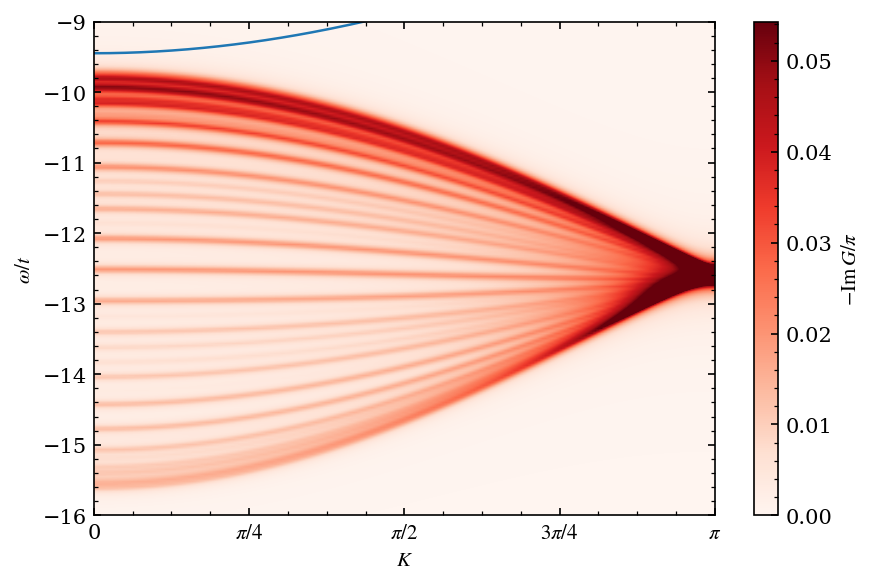

In [306]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(
    spectral_2d,
    origin='lower',
    extent=[k_values[0], k_values[-1], omega_values[0], omega_values[-1]],
    aspect='auto',
    cmap='Reds',
    interpolation='bilinear',
    vmin=0,
    vmax=np.percentile(spectral_2d, 99),
)

ax.set_xlabel(r'$K$')
ax.set_ylabel(r'$\omega / t$')
plt.plot(k_values, Delta-2*(t_c+t_v)*np.abs(np.cos(k_values/2)), color = "k", lw = 1)
plt.plot(k_values, Delta-np.sqrt(U**2 + 4 * (t_v**2 + t_c**2 + 2*t_c*t_v*np.cos(k_values))), ls = "--", color = "b", lw = 1)
plt.plot(k_values, -3/2*Je + J0 - 2*np.cos(k_values/2))
# Nice k-axis ticks
ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 4))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: {0: '0', 1: r'$\pi/4$', 2: r'$\pi/2$', 3: r'$3\pi/4$', 4: r'$\pi$'}
    .get(round(x / (np.pi/4)), f'{x:.2f}')
))
ax.set_ylim(omega_values[0], omega_values[-1])
fig.colorbar(im, ax=ax, label=r'$-\mathrm{Im}\,G / \pi$')
fig.tight_layout()
plt.show()


In [307]:
"""Spin-polaron + hole-spin-polaron continuum.

Both bands come from the SAME single-particle magnetic-polaron solver
(RealSpaceMagneticPolaron), called twice:

    electron polaron :  t = t_c ,  J_e = Je
    hole     polaron :  t = t_v ,  J_e = Jv

The joint lower edge at total momentum K is the free two-body minimum
    E_cont(K) = min_p [ E_sp^e(p) + E_sp^h(K - p) ] + energy_offset
"""
import numpy as np
from scipy.optimize import brentq


# =====================================================
# Single magnetic polaron (verbatim, unchanged)
# =====================================================
class RealSpaceMagneticPolaron:
    def __init__(self, t, J_0, J_e, s, gamma=1.0):
        self.t = float(t); self.J_0 = float(J_0); self.J_e = float(J_e)
        self.s = float(s); self.gamma = float(gamma)

    def denominator_real_below_continuum(self, omega, K):
        omega = float(omega); K = float(K)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        disc_real = disc.real
        if disc_real < 0:
            disc_real = 0.0
        sqrt_disc = np.sqrt(disc_real)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = rho1 if abs(rho1) < abs(rho2) else rho2
        beta = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * (self.s - 1.0)
        g2 = (self.gamma * self.J_e)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        return (omega + 2.0 * self.t * np.cos(K) + 0.5 * self.J_e * self.s - Sigma).real

    def sp_continuum_edge(self, K):
        K = float(K)
        q = np.linspace(-np.pi, np.pi, 5000)
        E = (-2.0 * self.t * np.cos(K - q)
             + 2.0 * self.J_0 * self.s * (1.0 - np.cos(q))
             + 0.5 * self.J_e * self.s)
        return np.min(E)


# =====================================================
# Lowest polaron band (verbatim helpers)
# =====================================================
def _lowest_root(D, p, w_lo, w_hi, n_scan, xtol):
    w = np.linspace(w_lo, w_hi, n_scan)
    Dw = np.array([D(x, p) for x in w])
    finite = np.isfinite(Dw)
    sc = np.flatnonzero(np.diff(np.signbit(Dw)) & finite[:-1] & finite[1:])
    if sc.size == 0:
        return None
    roots = []
    for i in sc:
        try:
            roots.append(brentq(lambda x: D(x, p), w[i], w[i + 1], xtol=xtol))
        except Exception:
            pass
    return min(roots) if roots else None


def extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0, padding=1e-8,
                                     n_scan=400, xtol=1e-12):
    n_p = len(p_grid)
    E_sp = np.full(n_p, np.nan)
    E_cont = np.array([pol.sp_continuum_edge(p) for p in p_grid])
    D = pol.denominator_real_below_continuum
    for j, p in enumerate(p_grid):
        w_hi = E_cont[j] - padding
        if w_hi <= wmin:
            continue
        root = _lowest_root(D, p, wmin, w_hi, n_scan, xtol)
        if root is None:
            for depth in range(8):
                w_lo = max(wmin, w_hi - 0.5 * 0.1**depth)
                if w_hi - w_lo < 1e-15:
                    break
                root = _lowest_root(D, p, w_lo, w_hi, n_scan, xtol)
                if root is not None:
                    break
        if root is not None:
            E_sp[j] = root
    return E_sp, E_cont


def wrap_to_bz(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi


# =====================================================
# NEW: build a polaron band from parameters
# =====================================================
def build_polaron_band(t, J_0, J_e, s, gamma, p_grid, *,
                       wmin=-8.0, n_scan=400):
    """Lowest single-polaron band E_sp(p) on p_grid for one particle."""
    pol = RealSpaceMagneticPolaron(t=t, J_0=J_0, J_e=J_e, s=s, gamma=gamma)
    E_sp, E_cont = extract_lowest_spin_polaron_band(
        pol, p_grid, wmin=wmin, n_scan=n_scan)
    return pol, E_sp, E_cont


# =====================================================
# NEW: spin-polaron + hole-spin-polaron continuum
# =====================================================
def two_polaron_continuum(K_ex_grid, p_grid, E_sp_e, E_sp_h,
                          *, energy_offset=0.0):
    """E_cont(K) = min_p [ E_sp_e(p) + E_sp_h(K - p) ] + energy_offset.

    E_sp_h is interpolated periodically over the BZ so that K - p can be
    evaluated at any momentum.  Grid points where either band has no bound
    pole (NaN) are dropped.
    """
    K_ex_grid = np.asarray(K_ex_grid, float)
    p_grid = np.asarray(p_grid, float)
    E_sp_e = np.asarray(E_sp_e, float)
    E_sp_h = np.asarray(E_sp_h, float)

    ve = np.isfinite(E_sp_e)
    vh = np.isfinite(E_sp_h)
    if not np.any(ve) or not np.any(vh):
        raise RuntimeError("electron or hole polaron band has no valid poles")

    p_e, Ee = p_grid[ve], E_sp_e[ve]        # minimise over these p
    p_h, Eh = p_grid[vh], E_sp_h[vh]        # interpolation nodes for the hole

    k_h = wrap_to_bz(K_ex_grid[:, None] - p_e[None, :])          # (nK, nP_e)
    order = np.argsort(p_h)
    Eh_interp = np.interp(k_h.ravel(), p_h[order], Eh[order],
                          period=2.0 * np.pi).reshape(k_h.shape)

    E_mat = Ee[None, :] + Eh_interp + energy_offset
    idx = np.argmin(E_mat, axis=1)
    rows = np.arange(K_ex_grid.size)
    E_cont = E_mat[rows, idx]
    p_star = p_e[idx]
    k_h_star = k_h[rows, idx]
    return E_cont, p_star, k_h_star

In [308]:
def spin_polaron_hole_continuum(K_grid, p_grid, E_sp, t_v, Jv, s, *, return_all=True):
    """
    Spin-polaron + free-hole continuum.

    Total momentum:
        K = p_sp + k_h

    Hole momentum:
        k_h = K - p_sp

    Hole dispersion:
        E_h(k_h) = -2 t_v cos(k_h)

    Continuum:
        E(K, p) = E_sp(p) - 2 t_v cos(K - p)

    Inputs
    ------
    K_grid : array
        Total exciton momentum grid.
    p_grid : array
        Spin-polaron momentum grid.
    E_sp : array
        Extracted spin-polaron dispersion on p_grid.
    t_v : float
        Hole hopping in the convention E_h(k) = -2 t_v cos(k).

    Returns
    -------
    E_low, E_high, p_star_low, p_star_high, k_h_low, k_h_high, E_all
    """
    K_grid = np.asarray(K_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    E_sp = np.asarray(E_sp, dtype=float)

    valid = np.isfinite(E_sp)
    if not np.any(valid):
        raise RuntimeError("E_sp contains no valid spin-polaron poles.")

    p_valid = p_grid[valid]
    E_valid = E_sp[valid]

    K2 = K_grid[:, None]
    P  = p_valid[None, :]

    k_h = K2 - P
    E_h = -2.0 * t_v * np.cos(k_h)

    E_all = E_valid[None, :] + E_h - Jv * s /2

    idx_low = np.argmin(E_all, axis=1)
    idx_high = np.argmax(E_all, axis=1)

    rows = np.arange(K_grid.size)

    E_low = E_all[rows, idx_low]
    E_high = E_all[rows, idx_high]

    p_star_low = p_valid[idx_low]
    p_star_high = p_valid[idx_high]

    k_h_low = k_h[rows, idx_low]
    k_h_high = k_h[rows, idx_high]

    if return_all:
        return E_low, E_high, p_star_low, p_star_high, k_h_low, k_h_high, p_valid, E_all

    return E_low, E_high, p_star_low, p_star_high, k_h_low, k_h_high

In [309]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_to_pi(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def exciton_bound_energy(k, t_c, t_v, U, Je=0.0, s=0.5):
    """
    Exact exciton bound-state dispersion in the reduced momentum variable k,
    where the formula depends on cos(k).

    k can be scalar or array.
    """
    A = t_c**2 + t_v**2 + 2.0*t_c*t_v*np.cos(k)
    E = -np.sqrt(U**2 + 4.0*A)   # lower / bound branch
    return E



def magnon_dispersion(q, J0, s, Je, Jv):
    """
    Exact 1D FM magnon dispersion in the same energy convention as your solver.
    """
    return 2.0*J0*s*(1.0 - np.cos(q)) + Je*s/2 + Jv*s/2

def exciton_magnon_continuum(K_grid, t_c, t_v, U, J0, s, Je=0.0, Jv=0.0,
                             nq=400):
    """
    Exciton + magnon continuum in the exciton-magnon solver convention.

    K_grid: solver momentum variable K in [0, pi]
    q: physical magnon momentum in [-pi, pi)
    Exciton reduced momentum is k_X = K - q, so cos( k_X) = cos(K - q).

    Returns:
      E_low(K), E_high(K), q_star_low(K), q_star_high(K), E_all(K,q)
    """
    K_grid = np.asarray(K_grid, dtype=float)
    q_grid = np.linspace(-np.pi, np.pi, nq, endpoint=False)

    # Broadcast over K and q
    K2 = K_grid[:, None]
    Q  = q_grid[None, :]

    # Exciton reduced momentum in your exact formula
    kX = K2 - Q

    EX = exciton_bound_energy(
        kX, t_c=t_c, t_v=t_v, U=U, Je=Je, s=s
    )
    WM = magnon_dispersion(Q, J0=J0, s=s, Je=Je, Jv=Jv)

    E_all = EX + WM

    idx_low  = np.argmin(E_all, axis=1)
    idx_high = np.argmax(E_all, axis=1)

    E_low  = E_all[np.arange(len(K_grid)), idx_low]
    E_high = E_all[np.arange(len(K_grid)), idx_high]

    q_star_low  = q_grid[idx_low]
    q_star_high = q_grid[idx_high]

    return E_low, E_high, q_star_low, q_star_high, q_grid, E_all

branch = above
valid = 200 / 200
min separation = 6.429539601708888
max separation = 9.624736700069139


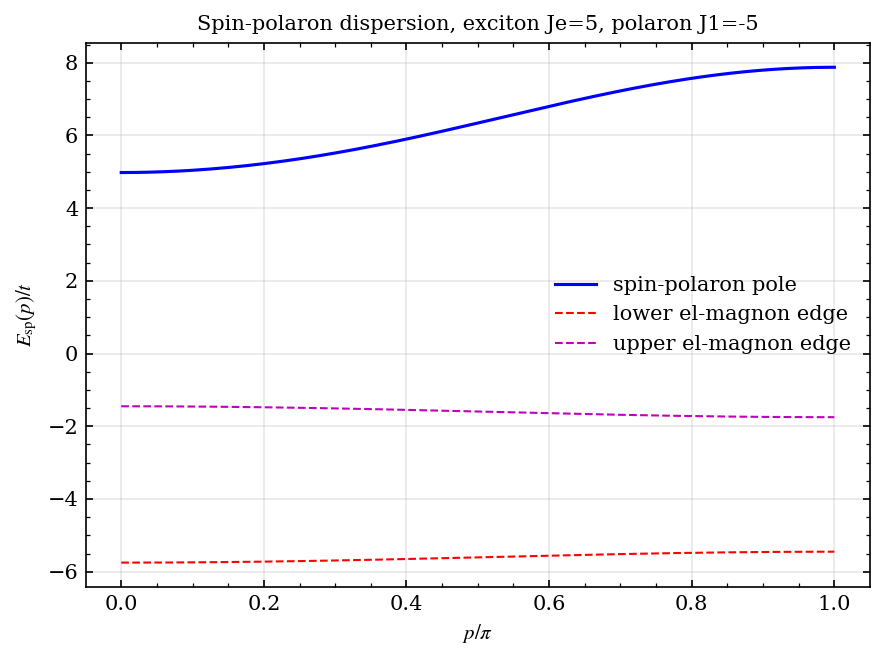

In [310]:
def em_edges_fast(pol, K):
    Aabs = abs(pol.t * np.exp(1j*K) + pol.J_0 * pol.s)
    center = 2.0 * pol.J_0 * pol.s + 0.5 * pol.J_e * pol.s
    return center - 2.0*Aabs, center + 2.0*Aabs


def self_energy_pole_energy(pol, K, branch):
    """
    Location where beta + 2 A_- rho = 0.
    The physical spin-polaron pole lies on the far side of this singularity.
    """
    J = pol.J_e
    Aabs = abs(pol.t * np.exp(1j*K) + pol.J_0 * pol.s)
    center = 2.0 * pol.J_0 * pol.s + 0.5 * J * pol.s

    alpha_abs = np.sqrt(4.0*Aabs*Aabs + 0.25*J*J)

    if branch == "below":
        return center - alpha_abs
    elif branch == "above":
        return center + alpha_abs
    else:
        raise ValueError("branch must be 'below' or 'above'")


def D_outside_fast(pol, omega, K, branch):
    J = pol.J_e

    if branch == "below":
        sigma = -1.0
    elif branch == "above":
        sigma = +1.0
    else:
        raise ValueError("branch must be 'below' or 'above'")

    Aabs = abs(pol.t * np.exp(1j*K) + pol.J_0 * pol.s)
    center = 2.0 * pol.J_0 * pol.s + 0.5 * J * pol.s

    alpha = omega - center
    rad = alpha*alpha - 4.0*Aabs*Aabs

    if rad <= 0.0:
        return np.nan

    root = np.sqrt(rad)
    denom_self = 0.5*J + sigma*root

    g2 = (pol.gamma * J)**2 * pol.s / 2.0

    return (
        omega
        + 2.0 * pol.t * np.cos(K)
        + 0.5 * J * pol.s
        - g2 / denom_self
    )

def extract_spin_polaron_band_fast(pol, p_grid,
                                   branch="auto",
                                   eps=1e-9,
                                   xtol=1e-11,
                                   rtol=1e-11,
                                   max_expand=30):
    """
    Fast extraction of the isolated spin-polaron pole.

    For polaron convention:
        J_e > 0: bound pole below continuum.
        J_e < 0: antibound pole above continuum.
    """
    p_grid = np.asarray(p_grid, dtype=float)

    if branch == "auto":
        if pol.J_e > 0:
            branch = "below"
        elif pol.J_e < 0:
            branch = "above"
        else:
            raise ValueError("pol.J_e = 0 has no spin-polaron pole.")

    if branch not in ("below", "above"):
        raise ValueError("branch must be 'auto', 'below', or 'above'.")

    E_sp = np.full_like(p_grid, np.nan, dtype=float)
    E_low = np.empty_like(p_grid, dtype=float)
    E_high = np.empty_like(p_grid, dtype=float)
    E_sing = np.empty_like(p_grid, dtype=float)

    scale = max(1.0, abs(pol.t), abs(pol.J_0*pol.s), abs(pol.J_e))

    for i, K in enumerate(p_grid):
        E_low[i], E_high[i] = em_edges_fast(pol, K)
        w_pole = self_energy_pole_energy(pol, K, branch)
        E_sing[i] = w_pole

        # The physical isolated pole is on the far side of the self-energy singularity.
        if branch == "below":
            b = w_pole - eps*scale
            fb = D_outside_fast(pol, b, K, branch)

            span = scale
            for _ in range(max_expand):
                a = w_pole - span
                fa = D_outside_fast(pol, a, K, branch)

                if np.isfinite(fa) and np.isfinite(fb) and fa*fb < 0.0:
                    E_sp[i] = brentq(
                        lambda w: D_outside_fast(pol, w, K, branch),
                        a, b,
                        xtol=xtol,
                        rtol=rtol,
                        maxiter=80,
                    )
                    break

                span *= 2.0

        else:
            a = w_pole + eps*scale
            fa = D_outside_fast(pol, a, K, branch)

            span = scale
            for _ in range(max_expand):
                b = w_pole + span
                fb = D_outside_fast(pol, b, K, branch)

                if np.isfinite(fa) and np.isfinite(fb) and fa*fb < 0.0:
                    E_sp[i] = brentq(
                        lambda w: D_outside_fast(pol, w, K, branch),
                        a, b,
                        xtol=xtol,
                        rtol=rtol,
                        maxiter=80,
                    )
                    break

                span *= 2.0

    return E_sp, E_low, E_high, E_sing, branch

J1_pol = -Je

pol = RealSpaceMagneticPolaron(
    t=t_c,
    J_0=J0,
    J_e=J1_pol,
    s=s,
    gamma=gamma,
)

p_grid = k_values

E_sp, E_low, E_high, E_sing, branch = extract_spin_polaron_band_fast(
    pol,
    p_grid,
    branch="auto",
)

print("branch =", branch)
print("valid =", np.sum(np.isfinite(E_sp)), "/", len(E_sp))

if branch == "below":
    sep = E_low - E_sp
else:
    sep = E_sp - E_high

print("min separation =", np.nanmin(sep))
print("max separation =", np.nanmax(sep))

fig, ax = plt.subplots(figsize=(6, 4.5))

ax.plot(p_grid / np.pi, E_sp, 'b-', lw=1.5, label='spin-polaron pole')
ax.plot(p_grid / np.pi, E_low, 'r--', lw=1, label='lower el-magnon edge')
ax.plot(p_grid / np.pi, E_high, 'm--', lw=1, label='upper el-magnon edge')

ax.set_xlabel(r'$p/\pi$')
ax.set_ylabel(r'$E_{\rm sp}(p)/t$')
ax.set_title(f'Spin-polaron dispersion, exciton Je={Je}, polaron J1={J1_pol}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#E_cont, p_star, k_h_star = spin_polaron_hole_continuum(
#    K_ex_grid=K_ex,
#    p_grid=p_grid,
#    E_sp=E_sp,
#    t_v=t_v,
#    Jv=-Jv,
#    s=s,
#)

In [311]:
def spin_polaron_hole_continuum(K_grid, p_grid, E_sp, t_v, Jv, s, *, return_all=True):
    """
    Spin-polaron + free-hole continuum.

    Total momentum:
        K = p_sp + k_h

    Hole momentum:
        k_h = K - p_sp

    Hole dispersion:
        E_h(k_h) = -2 t_v cos(k_h)

    Continuum:
        E(K, p) = E_sp(p) - 2 t_v cos(K - p)

    Inputs
    ------
    K_grid : array
        Total exciton momentum grid.
    p_grid : array
        Spin-polaron momentum grid.
    E_sp : array
        Extracted spin-polaron dispersion on p_grid.
    t_v : float
        Hole hopping in the convention E_h(k) = -2 t_v cos(k).

    Returns
    -------
    E_low, E_high, p_star_low, p_star_high, k_h_low, k_h_high, E_all
    """
    K_grid = np.asarray(K_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    E_sp = np.asarray(E_sp, dtype=float)

    valid = np.isfinite(E_sp)
    if not np.any(valid):
        raise RuntimeError("E_sp contains no valid spin-polaron poles.")

    p_valid = p_grid[valid]
    E_valid = E_sp[valid]

    K2 = K_grid[:, None]
    P  = p_valid[None, :]

    k_h = K2 - P
    E_h = -2.0 * t_v * np.cos(k_h)

    E_all = E_valid[None, :] + E_h - Jv * s /2

    idx_low = np.argmin(E_all, axis=1)
    idx_high = np.argmax(E_all, axis=1)

    rows = np.arange(K_grid.size)

    E_low = E_all[rows, idx_low]
    E_high = E_all[rows, idx_high]

    p_star_low = p_valid[idx_low]
    p_star_high = p_valid[idx_high]

    k_h_low = k_h[rows, idx_low]
    k_h_high = k_h[rows, idx_high]

    if return_all:
        return E_low, E_high, p_star_low, p_star_high, k_h_low, k_h_high, p_valid, E_all

    return E_low, E_high, p_star_low, p_star_high, k_h_low, k_h_high

In [312]:
J1_pol = -Je

pol = RealSpaceMagneticPolaron(
    t=t_c,
    J_0=J0,
    J_e=J1_pol,
    s=s,
    gamma=gamma,
)

p_grid = np.linspace(-np.pi, np.pi, 500, endpoint=False)

E_sp, E_low_sp, E_high_sp, E_sing, branch = extract_spin_polaron_band_fast(
    pol,
    p_grid,
    branch="auto",
)

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
#binding = E_sp_cont - E_sp
#print(f"  Min binding energy: {np.nanmin(binding):.6f}")
#print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values   # or np.linspace(0, np.pi, ...)
E_low_sp_h, E_high_sp_h, p_low, p_high, kh_low, kh_high, p_valid, E_all_sp_h = (
    spin_polaron_hole_continuum(
        K_grid=K_ex,
        p_grid=p_grid,
        E_sp=E_sp,
        t_v=t_v,
        Jv = Jv,
        s = s,
        return_all=True,
    )
)

  Found poles at 500/500 k-points


[electron] bound polaron band
[hole] bound polaron band


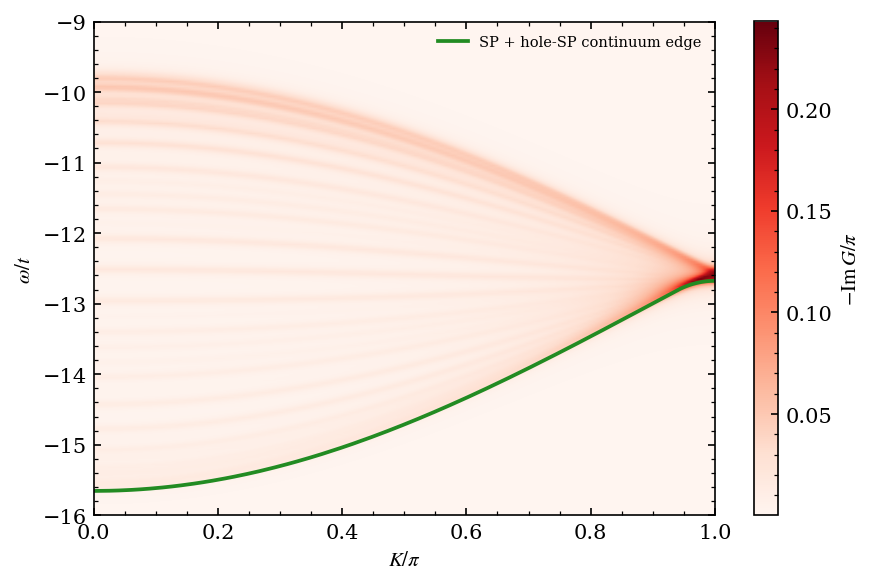

In [313]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#from polaron_continuum import build_polaron_band, two_polaron_continuum

# --- single source of truth for the k-axis: match the spectrum's columns ---
n_omega, n_k = spectral_2d.shape
k_values = np.linspace(0.0, np.pi, n_k)
omega_values = np.linspace(omega_values[0], omega_values[-1], n_omega)


# --- continuum on THIS k grid ---
p_grid = np.linspace(-np.pi, np.pi, 241)
_, E_e, Ec_e = build_polaron_band(t_c, J0, Je, s, gamma, p_grid)
_, E_h, Ec_h = build_polaron_band(t_v, J0, Jv, s, gamma, p_grid)

def _side(E, Ec, name):
    if np.mean(np.isfinite(E)) < 0.05:
        print(f"[{name}] no bound polaron -> continuum edge")
        return Ec
    print(f"[{name}] bound polaron band")
    return E

E_cont, p_star, k_h_star = two_polaron_continuum(
    k_values, p_grid,
    _side(E_e, Ec_e, "electron"),
    _side(E_h, Ec_h, "hole"),
    energy_offset=0.0,
)

assert E_cont.shape == k_values.shape, (E_cont.shape, k_values.shape)  # never drift again

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(
    spectral_2d, origin='lower',
    extent=[k_values[0]/np.pi, k_values[-1]/np.pi, omega_values[0], omega_values[-1]],
    aspect='auto', cmap='Reds', interpolation='bilinear', 
)
ax.set_xlabel(r'$K/\pi$')
ax.set_ylabel(r'$\omega / t$')

ax.plot(k_values/np.pi, E_cont, color='forestgreen', lw=1.8, label='SP + hole-SP continuum edge')
#ax.plot(k_values/np.pi, E_low_sp_h, label="spin-polaron+hole", lw=1.5)
#ax.plot(k_values/np.pi, E_low, color='y', label = "X+mag", lw=1.5)
ax.plot(k_values/np.pi, Delta - 2*(t_c+t_v)*np.abs(np.cos(k_values/2)), color='k', lw=1)
ax.plot(k_values/np.pi, Delta - np.sqrt(U**2 + 4*(t_v**2 + t_c**2 + 2*t_c*t_v*np.cos(k_values))),
        ls='--', color='b', lw=1)

#ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 4))
#ax.xaxis.set_major_formatter(ticker.FuncFormatter(
#    lambda x, _: {0: '0', 1: r'$\pi/4$', 2: r'$\pi/2$', 3: r'$3\pi/4$', 4: r'$\pi$'}
#    .get(round(x / (np.pi/4)), f'{x:.2f}')
#))
ax.set_ylim(omega_values[0], omega_values[-1])
ax.legend(fontsize=7, loc='upper right')
fig.colorbar(im, ax=ax, label=r'$-\mathrm{Im}\,G / \pi$')
fig.tight_layout()
plt.show()

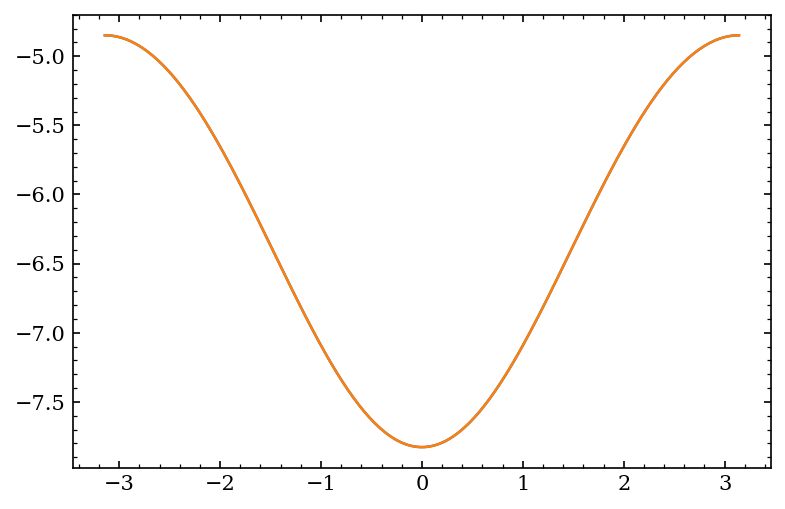

In [314]:
_, E_e, Ec_e = build_polaron_band(t_c, J0, Je, s, gamma, p_grid)
_, E_h, Ec_h = build_polaron_band(t_v, J0, Jv, s, gamma, p_grid)
plt.plot(p_grid,E_e)
plt.plot(p_grid,E_h)

In [315]:
import numpy as np
from scipy.interpolate import interp1d

def make_energy_interp(p_grid, E):
    """
    E(k) for arbitrary real k, using 2pi-periodicity and E(k) = E(-k).
    Assumes p_grid tabulates [0, pi].
    """
    interp = interp1d(p_grid, E, kind='cubic', bounds_error=False, fill_value='extrapolate')
    def E_of_k(k):
        k = np.mod(k + np.pi, 2*np.pi) - np.pi   # fold into [-pi, pi]
        k = np.abs(k)                             # fold into [0, pi]
        return interp(k)
    return E_of_k

_, E_e, Ec_e = build_polaron_band(t_c, J0, Je, s, gamma, p_grid)
_, E_h, Ec_h = build_polaron_band(t_v, J0, Jv, s, gamma, p_grid)

E_e_of_k = make_energy_interp(p_grid, E_e)
E_h_of_k = make_energy_interp(p_grid, E_h)

K_grid = np.linspace(0, np.pi, 400)          # E_th(K) is itself even, given both bands even
k_scan = np.linspace(-np.pi, np.pi, 2000)    # internal scan resolution — separate knob from K_grid

Ee_vals = E_e_of_k(k_scan)                              # (2000,)
Eh_vals = E_h_of_k(K_grid[:, None] - k_scan[None, :])   # (400, 2000)

S = Ee_vals[None, :] + Eh_vals
E_th   = S.min(axis=1)
k_star = k_scan[S.argmin(axis=1)]

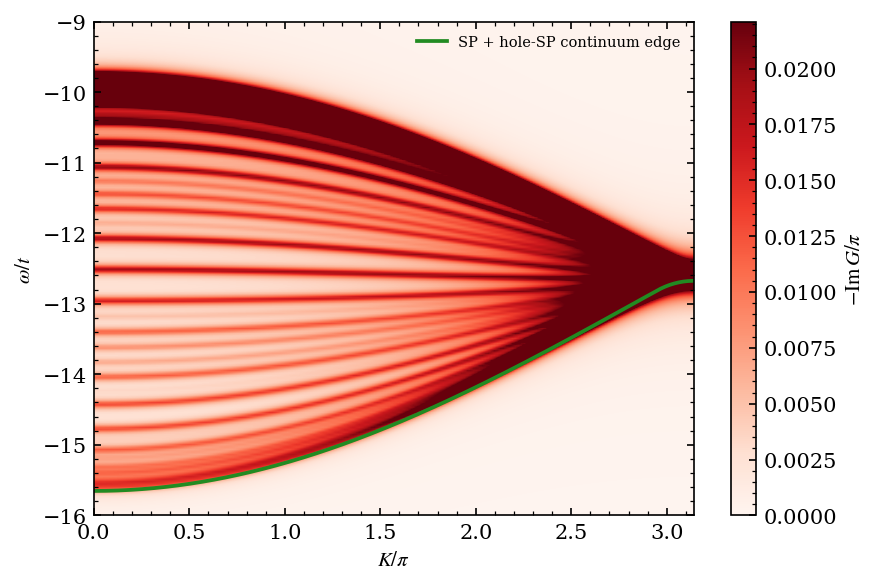

In [316]:
# --- plot ---
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(
    spectral_2d,
    origin='lower',
    extent=[k_values[0], k_values[-1], omega_values[0], omega_values[-1]],
    aspect='auto',
    cmap='Reds',
    interpolation='bilinear',
    vmin=0,
    vmax=np.percentile(spectral_2d, 89),
)
ax.set_xlabel(r'$K/\pi$')
ax.set_ylabel(r'$\omega / t$')

ax.plot(K_grid, E_th, color='forestgreen', lw=1.8, label='SP + hole-SP continuum edge')
#ax.plot(k_values/np.pi, E_low_sp_h, label="spin-polaron+hole", lw=1.5)
#ax.plot(k_values/np.pi, E_low, color='y', label = "X+mag", lw=1.5)
ax.plot(k_values/np.pi, Delta - 2*(t_c+t_v)*np.abs(np.cos(k_values/2)), color='k', lw=1)
ax.plot(k_values/np.pi, Delta - np.sqrt(U**2 + 4*(t_v**2 + t_c**2 + 2*t_c*t_v*np.cos(k_values))),
        ls='--', color='b', lw=1)

#ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 4))
#ax.xaxis.set_major_formatter(ticker.FuncFormatter(
#    lambda x, _: {0: '0', 1: r'$\pi/4$', 2: r'$\pi/2$', 3: r'$3\pi/4$', 4: r'$\pi$'}
#    .get(round(x / (np.pi/4)), f'{x:.2f}')
#))
ax.set_ylim(omega_values[0], omega_values[-1])
ax.legend(fontsize=7, loc='upper right')
fig.colorbar(im, ax=ax, label=r'$-\mathrm{Im}\,G / \pi$')
fig.tight_layout()
plt.show()

In [317]:
arr = np.array([
    [0.00915458, -9.67661692],
    [0.12514755, -9.67661692],
    [0.27274873, -9.65174129],
    [0.45724366, -9.61442786],
    [0.63116754, -9.55223881],
    [0.82614170, -9.45273632],
    [0.97366419, -9.35323383],
    [1.15805419, -9.21641791],
    [1.33189938, -9.07960199],
    [1.46883771, -8.94278607],
    [1.64791596, -8.76865672],
    [1.76376466, -8.63184080],
    [1.88491199, -8.51990050],
    [2.03238203, -8.37064677],
    [2.13771214, -8.25870647],
    [2.23778297, -8.15920398],
    [2.34839860, -8.05970149],
    [2.56962988, -7.86069652],
    [2.72768408, -7.74875622],
    [2.84359835, -7.67412935],
    [2.94373475, -7.63681592],
    [3.02808016, -7.62437811],
    [3.11769798, -7.61194030]
])


intp_cont = make_energy_interp(K_grid, E_th)

arr[:,1]- intp_cont(arr[:,0])

array([5.97705597, 5.9707249 , 5.97178898, 5.95475724, 5.94117868,
       5.92830562, 5.92424722, 5.91029615, 5.8845501 , 5.88032496,
       5.8541449 , 5.8526029 , 5.81317114, 5.76986092, 5.73930789,
       5.70007095, 5.64288955, 5.52016445, 5.39740303, 5.29839823,
       5.18523575, 5.09789868, 5.06567415])